<a href="https://colab.research.google.com/github/Rudragehlot/iris-classification-logistic-regression-My-first-ML-modul/blob/main/pridicting_salery_and_learning_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')


In [46]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("isaienkov/nba2k20-player-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nba2k20-player-dataset' dataset.
Path to dataset files: /kaggle/input/nba2k20-player-dataset


In [47]:
import os
print(os.listdir(path))

['nba2k-full.csv']


In [48]:
file_path = os.path.join(path, 'nba2k-full.csv')
df = pd.read_csv(file_path)
display(df.head())

,full_name,rating,jersey,team,position,b_day,height,weight,salary,country,draft_year,draft_round,draft_peak,college,version
0,LeBron James,97,#23,Los Angeles Lakers,F,12/30/84,6-9 / 2.06,250 lbs. / 113.4 kg.,$37436858,USA,2003,1,1,NaN,NBA2k20
1,Kawhi Leonard,97,#2,Los Angeles Clippers,F,06/29/91,6-7 / 2.01,225 lbs. / 102.1 kg.,$32742000,USA,2011,1,15,San Diego State,NBA2k20
2,Giannis Antetokounmpo,96,#34,Milwaukee Bucks,F-G,12/06/94,6-11 / 2.11,242 lbs. / 109.8 kg.,$25842697,Greece,2013,1,15,NaN,NBA2k20
3,Kevin Durant,96,#7,Brooklyn Nets,F,09/29/88,6-10 / 2.08,230 lbs. / 104.3 kg.,$37199000,USA,2007,1,2,Texas,NBA2k20
4,James Harden,96,#13,Houston Rockets,G,08/26/89,6-5 / 1.96,220 lbs. / 99.8 kg.,$38199000,USA,2009,1,3,Arizona State,NBA2k20


In [49]:
df.shape

(464, 15)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464 entries, 0 to 463
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   full_name    464 non-null    object
 1   rating       464 non-null    int64 
 2   jersey       464 non-null    object
 3   team         441 non-null    object
 4   position     464 non-null    object
 5   b_day        464 non-null    object
 6   height       464 non-null    object
 7   weight       464 non-null    object
 8   salary       464 non-null    object
 9   country      464 non-null    object
 10  draft_year   464 non-null    int64 
 11  draft_round  464 non-null    object
 12  draft_peak   464 non-null    object
 13  college      388 non-null    object
 14  version      464 non-null    object
dtypes: int64(2), object(13)
memory usage: 54.5+ KB


In [50]:
df=df.dropna()

In [51]:
df.isnull().sum().sum()

np.int64(0)

In [52]:
df=df.drop(['full_name','b_day','height','weight','college','version'], axis=1)
df.head()

,rating,jersey,team,position,salary,country,draft_year,draft_round,draft_peak
1,97,#2,Los Angeles Clippers,F,$32742000,USA,2011,1,15
3,96,#7,Brooklyn Nets,F,$37199000,USA,2007,1,2
4,96,#13,Houston Rockets,G,$38199000,USA,2009,1,3
5,95,#30,Golden State Warriors,G,$40231758,USA,2009,1,7
6,94,#3,Los Angeles Lakers,F-C,$27093019,USA,2012,1,1


In [53]:
def remove_hash(value):
  value=value[1:]
  return int(value)
df['jersey']= df['jersey'].apply(remove_hash)


In [54]:
df['salary']= df['salary'].apply(remove_hash)

In [55]:
df.head()

,rating,jersey,team,position,salary,country,draft_year,draft_round,draft_peak
1,97,2,Los Angeles Clippers,F,32742000,USA,2011,1,15
3,96,7,Brooklyn Nets,F,37199000,USA,2007,1,2
4,96,13,Houston Rockets,G,38199000,USA,2009,1,3
5,95,30,Golden State Warriors,G,40231758,USA,2009,1,7
6,94,3,Los Angeles Lakers,F-C,27093019,USA,2012,1,1


In [56]:
df['team'].value_counts()

,count
team,
Brooklyn Nets,17
Los Angeles Clippers,15
Los Angeles Lakers,15
Philadelphia 76ers,14
New Orleans Pelicans,14
Indiana Pacers,14
Milwaukee Bucks,14
Orlando Magic,14
New York Knicks,13


In [57]:
df['country'].value_counts()

,count
country,
USA,315
Canada,15
Australia,8
Cameroon,5
Nigeria,3
The Bahamas,2
Ukraine,2
Finland,1
Dominican Republic,1


In [58]:
def remove_contry(value):
  if value not in ['USA','Canada','Australia']:
    return 'other'
  else:
    return value
df['country']= df['country'].apply(remove_contry)
df['country'].value_counts()

,count
country,
USA,315
other,31
Canada,15
Australia,8


In [59]:
df['position'].value_counts()

,count
position,
G,166
F,123
C,31
F-C,26
G-F,11
F-G,7
C-F,5


In [60]:
df.head()

,rating,jersey,team,position,salary,country,draft_year,draft_round,draft_peak
1,97,2,Los Angeles Clippers,F,32742000,USA,2011,1,15
3,96,7,Brooklyn Nets,F,37199000,USA,2007,1,2
4,96,13,Houston Rockets,G,38199000,USA,2009,1,3
5,95,30,Golden State Warriors,G,40231758,USA,2009,1,7
6,94,3,Los Angeles Lakers,F-C,27093019,USA,2012,1,1


In [65]:
df['draft_round'].unique()

array(['1', '2', 'Undrafted'], dtype=object)

In [63]:
df['draft_peak'].unique()

array(['15', '2', '3', '7', '1', '10', '6', '4', '11', '30', '13', '9',
       '27', '5', '35', '17', '16', '18', '19', '24', '39', '36', '32',
       '12', '38', '47', '8', '33', 'Undrafted', '40', '14', '22', '42',
       '46', '20', '29', '26', '51', '45', '43', '34', '21', '23', '44',
       '28', '37', '55', '25', '41', '49', '50', '31', '52', '54', '48',
       '58', '60'], dtype=object)

In [66]:
def remove_undif(value):
  if value =='Undrafted':
    return
  else:
    return value
df['draft_round']= df['draft_round'].apply(remove_undif)
df['draft_peak']= df['draft_peak'].apply(remove_undif)


In [67]:
df=df.dropna()

In [69]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['position']=le.fit_transform(df['position'])
df['country']=le.fit_transform(df['country'])
df['team']=le.fit_transform(df['team'])

df.head()

,rating,jersey,team,position,salary,country,draft_year,draft_round,draft_peak
1,97,2,12,2,32742000,2,2011,1,15
3,96,7,2,2,37199000,2,2007,1,2
4,96,13,10,5,38199000,2,2009,1,3
5,95,30,9,5,40231758,2,2009,1,7
6,94,3,13,3,27093019,2,2012,1,1


In [71]:
df.describe()

,rating,jersey,team,position,salary,country,draft_year
count,317.000000,317.000000,317.000000,317.000000,3.170000e+02,317.000000,317.000000
mean,78.337539,13.839117,14.665615,3.362776,1.145762e+07,2.015773,2014.066246
std,6.820688,14.861682,8.431886,1.742326,1.178645e+07,0.439077,3.915891
min,68.000000,0.000000,0.000000,0.000000,7.956800e+04,0.000000,2003.000000
25%,73.000000,3.000000,8.000000,2.000000,2.351838e+06,2.000000,2011.000000
50%,77.000000,10.000000,15.000000,3.000000,6.500000e+06,2.000000,2015.000000
75%,82.000000,22.000000,22.000000,5.000000,1.564375e+07,2.000000,2017.000000
max,97.000000,99.000000,29.000000,6.000000,4.578097e+07,3.000000,2019.000000


In [72]:
x=df.drop(['salary'], axis=1)
y=df['salary']

In [74]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_=train_test_split(x,y,test_size=0.2)


In [77]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
pridiction=lr.predict(x_test)

In [78]:
diff=y_test-pridiction

/tmp/ipykernel_6854/1965392350.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(diff)


<Axes: xlabel='salary', ylabel='Density'>

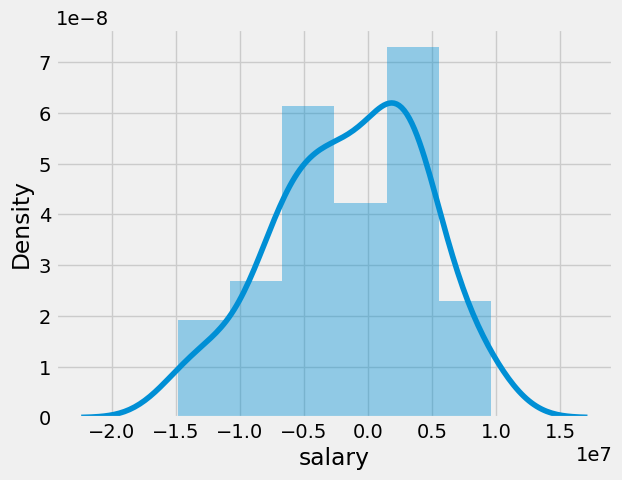

In [80]:
import seaborn as sns
sns.distplot(diff)


In [82]:
import pickle
pickle.dump(lr,open('./model.sev','wb'))